In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [90]:
df = pd.read_csv('/content/heart_disease_uci.csv')
print("\nІнформація про типи даних:")
df.info()
print("\nПерші 10 рядків датасету:")
print(df.head(10))

print("\nСтатистичний опис числових ознак:")
df.describe()


Інформація про типи даних:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Перші 10 рядків датасету:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [91]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62
slope,309
ca,611
thal,486


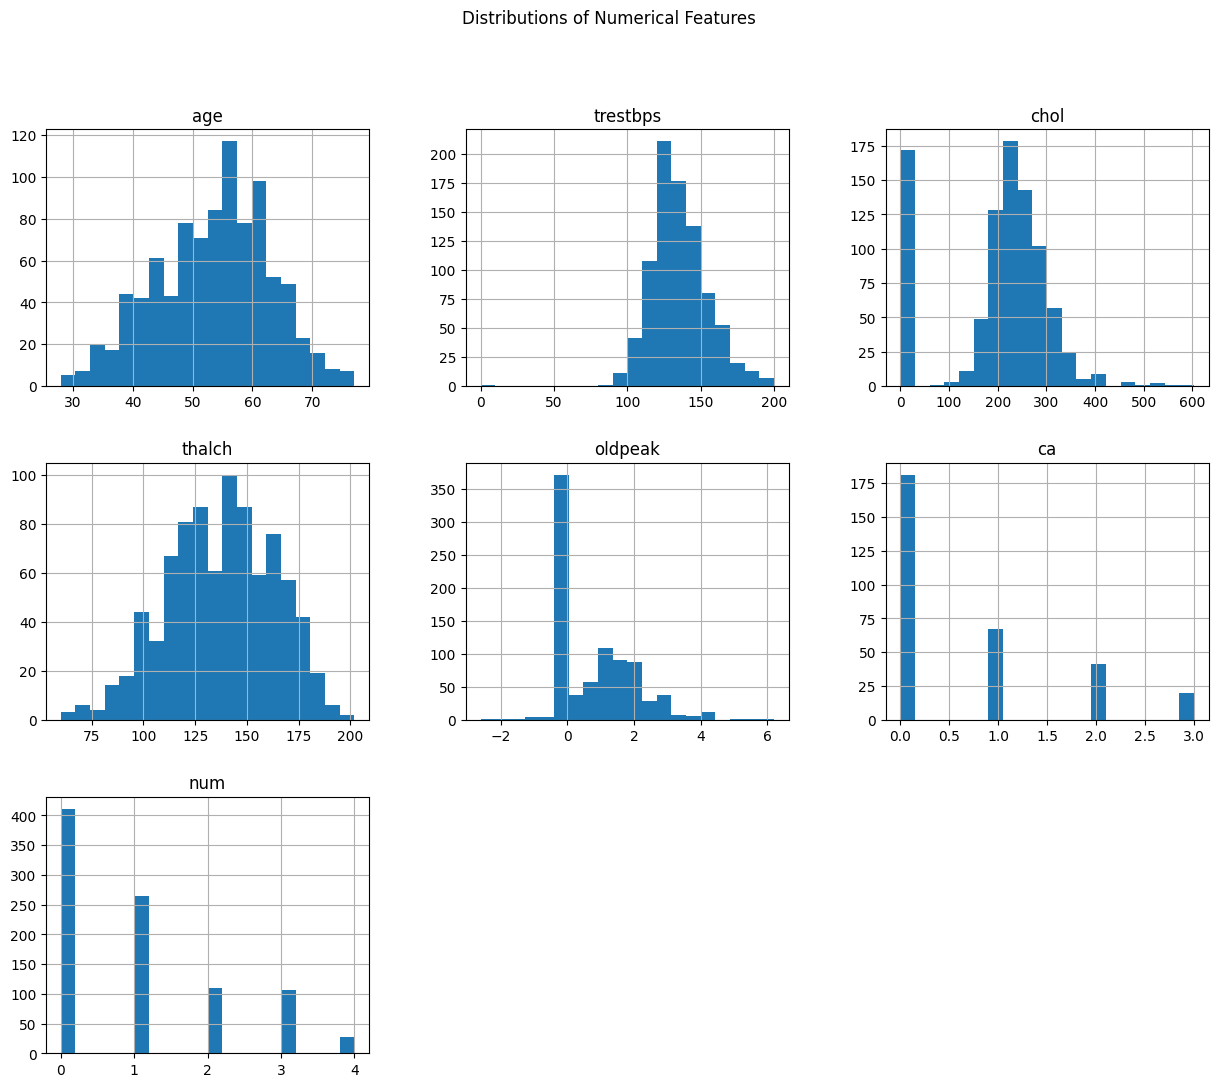

In [92]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('id')
df[numeric_cols].hist(figsize=(15,12), bins=20)
plt.suptitle('Distributions of Numerical Features')
plt.show()

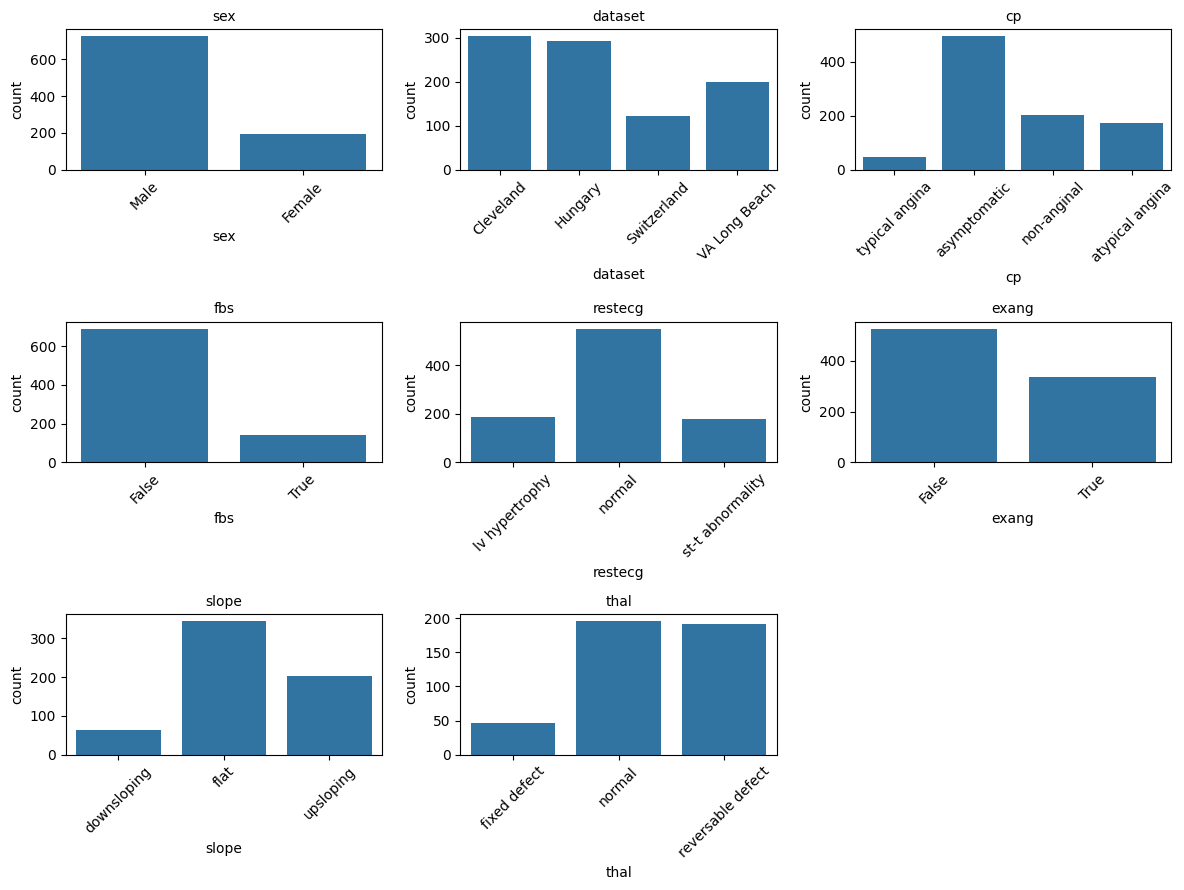

In [93]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 4, n_rows * 3)
)

axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(categorical_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

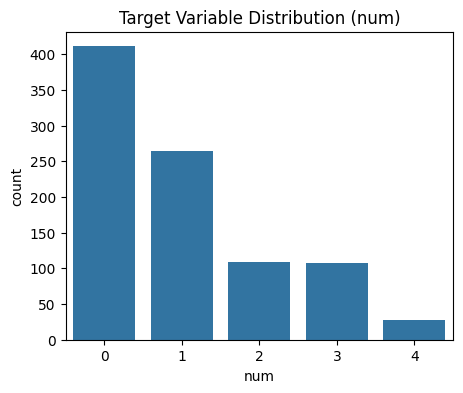

In [94]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='num')
plt.title('Target Variable Distribution (num)')
plt.show()

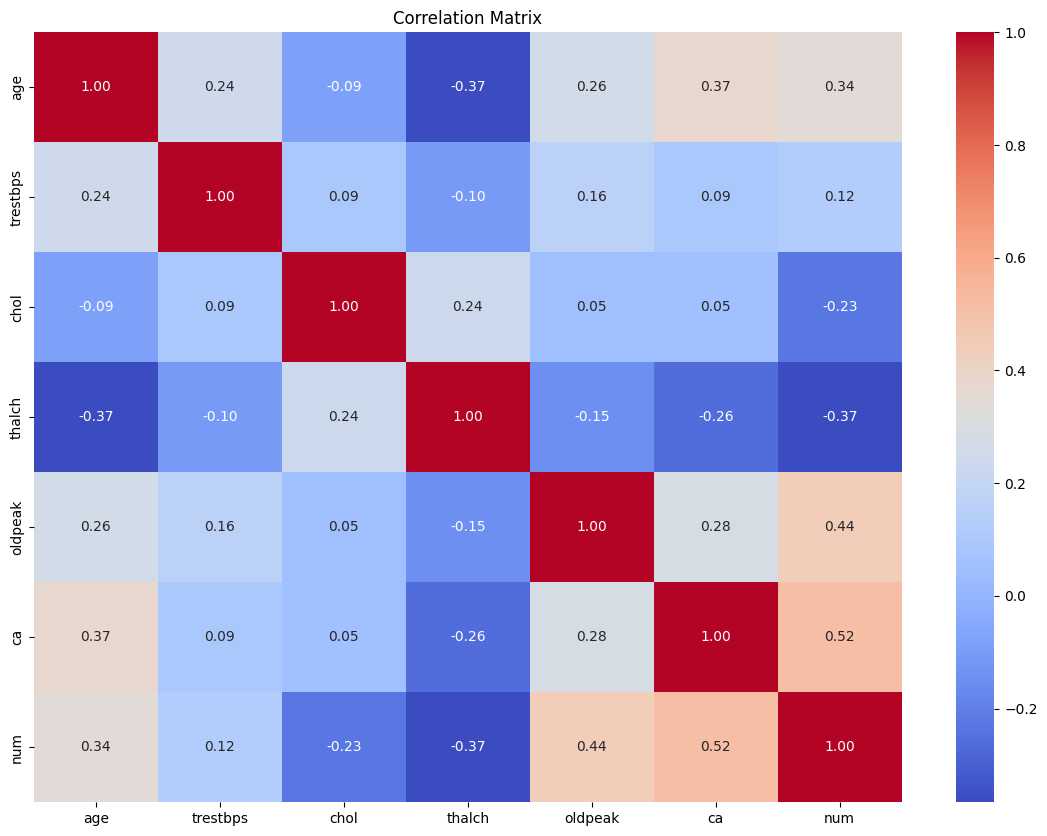

In [95]:
plt.figure(figsize=(14,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [96]:
num_features = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_features = ['fbs', 'restecg', 'exang', 'slope', 'thal']

for col in num_features:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

for col in cat_features:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

df.isnull().sum()

/tmp/ipython-input-1837210703.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_value)


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [97]:
X = df.drop(columns=['num', 'id', 'dataset'])
y = (df['num'] > 0).astype(int)
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class='ovr'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    )
}

In [99]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba[:, 1])
    }

    return metrics, y_pred

In [101]:
results = {}
predictions = {}

for name, model in models.items():
    metrics, y_pred = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
    results[name] = metrics
    predictions[name] = y_pred
results_df = pd.DataFrame(results).T
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,Accuracy,Precision,Recall,F1-score,AUC-ROC
Logistic Regression,0.842391,0.841121,0.882353,0.861244,0.903156
Random Forest,0.847826,0.842593,0.892157,0.866667,0.903216
SVM (RBF),0.853261,0.831858,0.921569,0.874419,0.919177


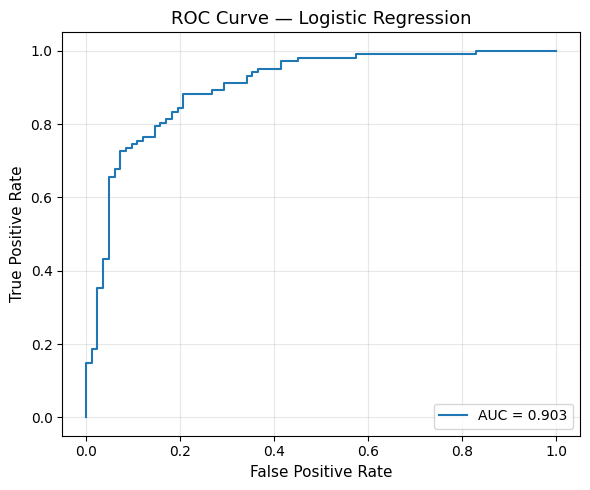

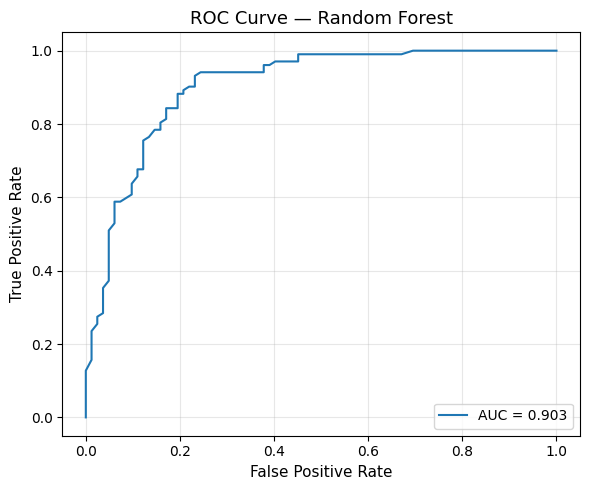

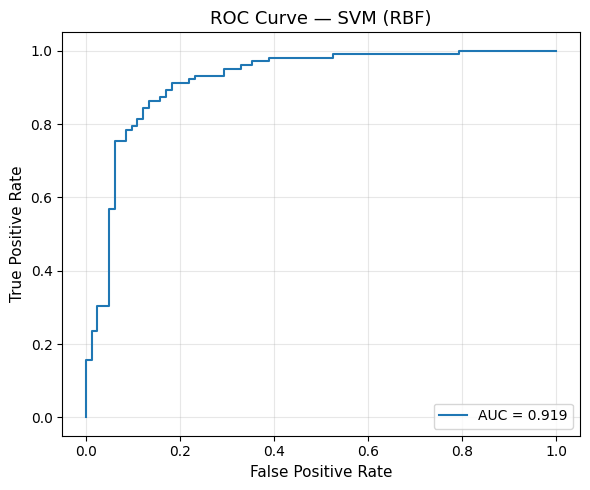

In [102]:
def plot_binary_roc(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.title(f"ROC Curve — {model_name}", fontsize=13)
    plt.legend(loc="lower right", frameon=True)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

for name, model in models.items():
    plot_binary_roc(
        model,
        X_test_scaled,
        y_test,
        name
    )


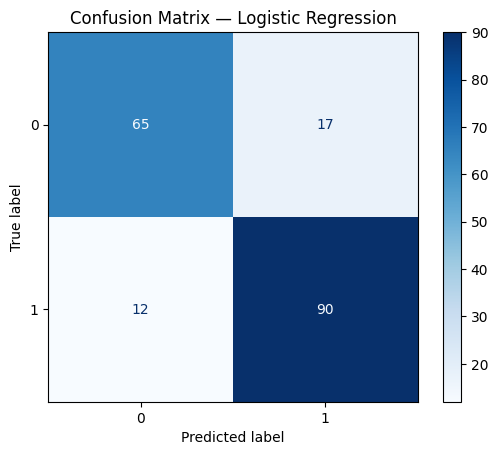

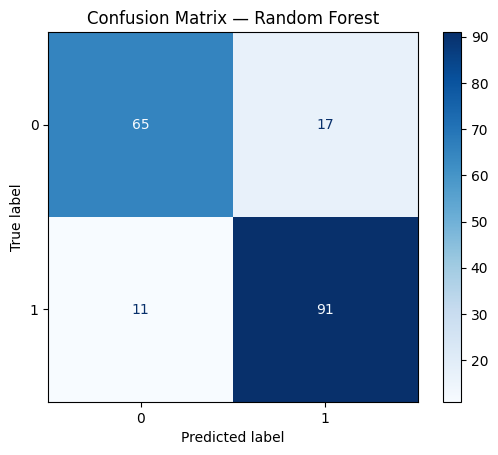

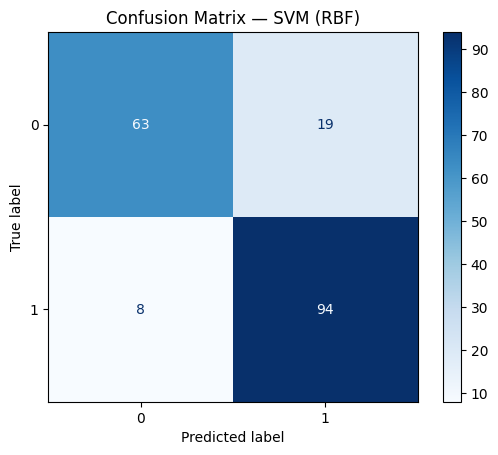

In [103]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )

    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()


In [104]:
best_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
best_model.fit(X_train_scaled, y_train)
joblib.dump(best_model, '/content/svm_heart_disease_model.pkl')
joblib.dump(scaler, '/content/scaler.pkl')
joblib.dump(X.columns.tolist(), '/content/feature_columns.pkl')

['/content/feature_columns.pkl']